# Solving XOR using Multi-Layer Perceptron (MLP) from Scratch

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

%matplotlib inline

In [2]:
def prepare_data():
    X = np.array([
        [0,0], [0,1], [1,0], [1,1]])
    y = np.array([0,1,1,0])

    return X, y

In [3]:
def build_model(hidden_neurons=4, activation='logistic', solver='lbfgs', max_iter=2000):
    model = MLPClassifier(
        hidden_layer_sizes=(hidden_neurons,), 
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        random_state=42
    )
    return model

In [4]:
def train_model(model, X, y):
    model.fit(X,y)
    return model

In [5]:
def evaluate_model(model, X, y):
    accuracy = model.score(X, y)
    predictions = model.predict(X)
    print(f"Accuracy: {accuracy*100:.2f}%")
    print("Predictions:", predictions)
    return accuracy, predictions

In [6]:
def plot_decision_boundary(model, X, y, accuracy):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                     np.linspace(-0.5, 1.5, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points).reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # Plot class 0 points
    plt.scatter(X[y == 0, 0], X[y == 0, 1],
                c='blue', edgecolors='k', s=100, label='Class 0')

    # Plot class 1 points
    plt.scatter(X[y == 1, 0], X[y == 1, 1],
                c='red', edgecolors='k', s=100, label='Class 1')

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('MLP Decision Boundary for XOR')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.show()


In [7]:
X, y = prepare_data()

In [8]:
mlp_model = build_model()

In [9]:
mlp_model = train_model(mlp_model, X, y)

In [10]:
accuracy, predictions = evaluate_model(mlp_model, X, y)

Accuracy: 100.00%
Predictions: [0 1 1 0]


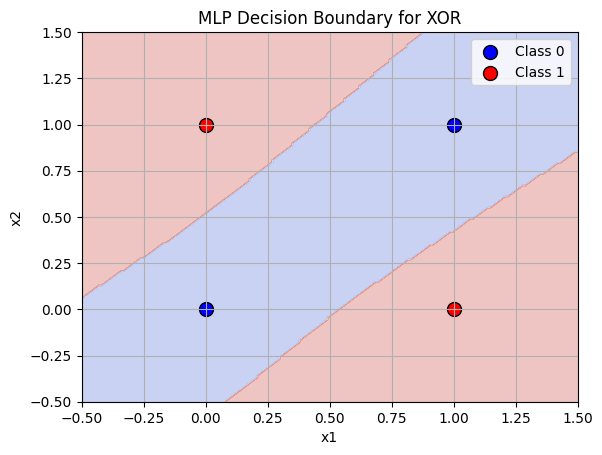

In [11]:
plot_decision_boundary(mlp_model, X, y, accuracy)